# 06 — Causal Forest (CausalForestDML)

| | |
|---|---|
| **Entradas** | `data/causal_forest_train.csv`, `data/causal_forest_test.csv` (gerados pelo notebook 01) |
| **Saídas** | `Overleaf Latex/figs/cf_cate_distribuicao.png`, linha CF em `data/metricas_comparativo.csv` |
| **Ordem** | 6º — independente de GAM e BSTS; depende apenas do notebook 01 |


In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


## Causal Forests

**Biblioteca:** `econml` — `CausalForestDML` (Microsoft)

**Estrutura causal:**
- **Y (outcome):** `br_ibov_ret_log` — retorno diário do Ibovespa
- **T (tratamento):** `T_choque_dolar` — dias com variação cambial ≥ percentil 75 (em valor absoluto)
- **X (covariáveis):** demais variáveis macroeconômicas

O objetivo é estimar o **efeito causal heterogêneo** do choque cambial sobre o retorno do Ibovespa, condicionado ao contexto macroeconômico (Selic alta vs baixa, risco-país elevado, etc.).

In [2]:
# Causal Forest - instalacao e imports
try:
    from econml.dml import CausalForestDML
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "econml", "-q"])
    from econml.dml import CausalForestDML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("econml / CausalForestDML disponivel.")


econml / CausalForestDML disponivel.


In [3]:
# Carrega dados do Causal Forest (gerados pelo notebook 01)
import numpy as np
import pandas as pd

df_cf_train = pd.read_csv(str(DATA_DIR / 'causal_forest_train.csv'), index_col=0, parse_dates=True)
df_cf_test  = pd.read_csv(str(DATA_DIR / 'causal_forest_test.csv'),  index_col=0, parse_dates=True)

TARGET_CF = 'br_ibov_ret_log'
TREAT_CF  = 'T_choque_dolar'
# br_dolar_diff excluída: T é função determinística dela (vazamento causal)
DROP_CF   = [TARGET_CF, TREAT_CF, 'br_dolar_diff']
COVS_CF   = [c for c in df_cf_train.columns if c not in DROP_CF]

y_cf_train = df_cf_train[TARGET_CF].values
T_cf_train = df_cf_train[TREAT_CF].values
X_cf_train = df_cf_train[COVS_CF].values

y_cf_test = df_cf_test[TARGET_CF].values
T_cf_test = df_cf_test[TREAT_CF].values
X_cf_test = df_cf_test[COVS_CF].values

print(f"Treino: {X_cf_train.shape[0]} obs | Teste: {X_cf_test.shape[0]} obs")
print(f"Covariáveis ({len(COVS_CF)}): {COVS_CF}")
print(f"Prevalência T=1 treino: {T_cf_train.mean():.1%} | teste: {T_cf_test.mean():.1%}")


Treino: 4481 obs | Teste: 1117 obs
Covariáveis (5): ['br_selic_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']
Prevalência T=1 treino: 25.0% | teste: 55.9%


In [4]:
# Causal Forest - ajuste do modelo (CF0, configuracao base sem tuning)
# T binario -> discrete_treatment=True. Nuisance models: GradientBoosting.
cf_model = CausalForestDML(
    model_y=GradientBoostingRegressor(random_state=42),
    model_t=GradientBoostingClassifier(random_state=42),
    discrete_treatment=True,
    n_estimators=2000,
    min_samples_leaf=10,
    random_state=42,
)
cf_model.fit(Y=y_cf_train, T=T_cf_train, X=X_cf_train)

cf_ate = float(cf_model.ate(X_cf_test))
cf_ate_lb, cf_ate_ub = cf_model.ate_interval(X_cf_test, alpha=0.05)
cf_ate_lb, cf_ate_ub = float(cf_ate_lb), float(cf_ate_ub)

print("Causal Forest (CF0) ajustado.")
print(f"ATE (efeito causal medio do choque cambial no retorno log do Ibovespa): {cf_ate:.6f}")
print(f"IC 95%: [{cf_ate_lb:.6f}, {cf_ate_ub:.6f}]")
sig = "SIM" if (cf_ate_lb > 0 or cf_ate_ub < 0) else "NAO"
print(f"Efeito estatisticamente distinto de zero a 95%: {sig}")


Causal Forest (CF0) ajustado.
ATE (efeito causal medio do choque cambial no retorno log do Ibovespa): -0.000002
IC 95%: [-0.004325, 0.004322]
Efeito estatisticamente distinto de zero a 95%: NAO


Distribuicao do CATE (teste):
  min=-0.009483  mediana=0.000045  max=0.012974
  desvio-padrao=0.002896  % efeitos negativos=49.5%


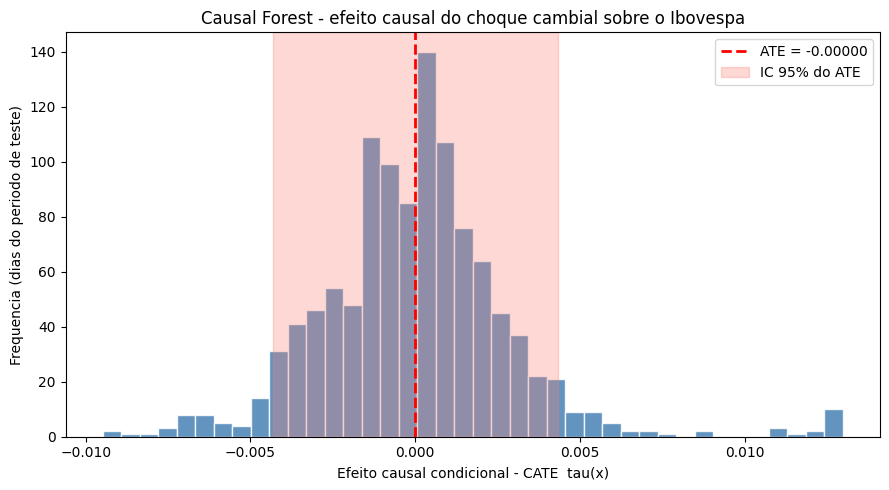


Reconstrucao preditiva (Y_hat = m0(X) + tau(X)*T):
  MAE=0.010442  RMSE=0.014925  R2=0.2387


In [5]:
# Causal Forest - CATE no teste, figura e reconstrucao preditiva
cate_test = cf_model.effect(X_cf_test)
cate_lb, cate_ub = cf_model.effect_interval(X_cf_test, alpha=0.05)

print("Distribuicao do CATE (teste):")
print(f"  min={cate_test.min():.6f}  mediana={np.median(cate_test):.6f}  max={cate_test.max():.6f}")
print(f"  desvio-padrao={cate_test.std():.6f}  % efeitos negativos={np.mean(cate_test < 0)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cate_test, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(cf_ate, color='red', linestyle='--', linewidth=2, label=f'ATE = {cf_ate:.5f}')
ax.axvspan(cf_ate_lb, cf_ate_ub, color='salmon', alpha=0.3, label='IC 95% do ATE')
ax.set_xlabel('Efeito causal condicional - CATE  tau(x)')
ax.set_ylabel('Frequencia (dias do periodo de teste)')
ax.set_title('Causal Forest - efeito causal do choque cambial sobre o Ibovespa')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "cf_cate_distribuicao.png"), dpi=150, bbox_inches="tight")
plt.show()

# Reconstrucao preditiva para a tabela comparativa:
# Y_hat = m0(X) + tau(X) * T, com m0 = regressao do desfecho nos dias de controle do treino.
base_ctrl = GradientBoostingRegressor(random_state=42)
base_ctrl.fit(X_cf_train[T_cf_train == 0], y_cf_train[T_cf_train == 0])
y_cf_hat = base_ctrl.predict(X_cf_test) + cate_test * T_cf_test

cf_mae  = mean_absolute_error(y_cf_test, y_cf_hat)
cf_rmse = np.sqrt(mean_squared_error(y_cf_test, y_cf_hat))
cf_r2   = r2_score(y_cf_test, y_cf_hat)
print(f"\nReconstrucao preditiva (Y_hat = m0(X) + tau(X)*T):")
print(f"  MAE={cf_mae:.6f}  RMSE={cf_rmse:.6f}  R2={cf_r2:.4f}")


## Registro de Métricas

In [6]:
# Registra métricas do Causal Forest em data/metricas_comparativo.csv
registrar_metricas(
    'Causal Forest',
    r2_base=None,
    mae_base=None,
    r2_teste=round(float(cf_r2), 4),
    mae_teste=round(float(cf_mae), 6),
    rmse_teste=round(float(cf_rmse), 6),
    extras={
        'ate':    round(float(cf_ate), 6),
        'ate_lb': round(float(cf_ate_lb), 6),
        'ate_ub': round(float(cf_ate_ub), 6),
        'covariates': COVS_CF,
    }
)

print(f"Causal Forest — MAE: {cf_mae:.6f} | RMSE: {cf_rmse:.6f} | R2: {cf_r2:.4f}")
print(f"ATE: {cf_ate:.6f}  IC 95%: [{cf_ate_lb:.6f}, {cf_ate_ub:.6f}]")


[metricas_comparativo] 'Causal Forest' → metricas_comparativo.csv
Causal Forest — MAE: 0.010442 | RMSE: 0.014925 | R2: 0.2387
ATE: -0.000002  IC 95%: [-0.004325, 0.004322]
